In [56]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [57]:
generator_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)
evaluator_llm = ChatNVIDIA(model="nvidia/nemotron-3-super-120b-a12b", temperature=0)
optimizer_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.2)

In [58]:
from pydantic import BaseModel, Field
from typing import Literal

class TweetEvaluation(BaseModel):
    evaluation: Literal["Approved", "Needs_Improvement"] = Field(
        description="Whether the tweet is approved or needs improvement"
    )
    feedback: str = Field(
        description="Feedback or suggestions for improvement if the tweet needs improvement"
    )

In [59]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [60]:
# state
class TweetState(TypedDict):

    topic:str
    tweet:str
    evaluation: Literal["Approved","Needs_Improvement"]
    feedback:str
    iteration:int
    max_iterations: int 

    tweet_history : Annotated[list[str], operator.add]
    feedback_history : Annotated[list[str], operator.add]
    

In [61]:
def generate_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
    """)
    ]

    # generator
    response= generator_llm.invoke(messages).content

    # return response
    return {'tweet':response, 
            'tweet_history':[response],
            "feedback_history":[],
            "iteration":1
            }
    

In [62]:
def evaluate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality - Is this fresh, or have you seen it a hundred times before?
2. Humor - Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness - Is it short, sharp, and scroll-stopping?
4. Virality Potential - Would people retweet or share it?
5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle universe" or vague summaries)

### Respond ONLY in structured format:
- evaluation: "Approved" or "Needs_Improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
    ]
    
    # We will use our strict evaluator LLM here to ensure it adheres closely to these instructions
    response = structured_evaluator_llm.invoke(messages)
    
    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback,
        "feedback_history":[response.feedback]
    }

In [63]:
from langchain_core.messages import SystemMessage, HumanMessage

def optimize_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    
    # Run via optimizer model
    response = optimizer_llm.invoke(messages).content
    iteration = state["iteration"] + 1
    
    return {
        "tweet": response,
        "iteration": iteration,
        'tweet_history': [response],
    }

In [64]:
def route_evaluation(state:TweetState):
    if state['evaluation']=='Approved' or state['iteration'] >= state['max_iterations']:
        return 'Approved'
    else:
        return 'Needs_Improvement'


In [65]:
graph = StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {"Approved": END, "Needs_Improvement": 'optimize'})
graph.add_edge('optimize', 'evaluate')  # Loop back to evaluation after optimization

workflow= graph.compile()

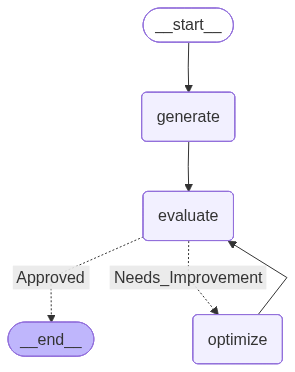

In [66]:
workflow

In [67]:
initial_state = {
    'topic': "Computer Science Major",
    'iteration':1,
    'max_iterations': 5
}
workflow.invoke(initial_state)

{'topic': 'Computer Science Major',
 'tweet': "Computer Science major: 10 hours debugging code, 0 hours explaining it to grandma. Now she thinks I'm a magician who broke the Wi-Fi #CSLife",
 'evaluation': 'Approved',
 'feedback': 'The tweet is concise, relatable, and lands a light-hearted punch about the mystique non‑technical folks assign to programmers. It avoids the forbidden Q&A or setup‑punchline structures and stays well within the character limit. While the core idea of a grandma mistaking coding skill for magic is a familiar trope, the specific wording and the #CSLife tag give it enough freshness to elicit a chuckle and make it shareable among CS students and tech‑savvy audiences.',
 'iteration': 2,
 'max_iterations': 5,
 'tweet_history': ['Computer Science major: spends 8\u202fhours a day arguing with a compiler, 2\u202fhours on Stack\u202fOverflow, and still can’t explain to grandma why the Wi‑Fi is down. #CSLife',
  "Computer Science major: 10 hours debugging code, 0 hours e